# Project: Expert Discovery System and Collaboration Network Analysis with HORUS data

**General Objective**: To develop an intelligent model that identifies latent areas of expertise and recommends thesis advisors based on semantic affinity, overcoming traditional administrative classifications.

**Main Mining Technique**: Topic detection (Topic Modeling) with the use of embeddings (Language Models - LLMs) for vector representation of descriptions (e.g., SBERT or ada-002) combined with Hierarchical Clustering (e.g., HDBSCAN).

**Granularity level**: The base level of granularity is academic productions. For now, data has been collected from a single university campus (sede Bogotá) and its faculties (without a more specific breakdown by departments, mainly for ease of extraction, as we have not yet been given access to the official databases). However, I this would still be acceptable to a certain extent, as the focus is on professors and their output rather than on any divisions that may exist, allowing the data to reveal the actual structure of research  (thematic affinity rather than by faculty or department). Also, we will only consider productions of active professors.

# 1. Setup and imports

In [1]:
import pandas as pd
import numpy as np
import re
import unicodedata
from itertools import combinations
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import gc

import os
from pathlib import Path

### 1.1. Environment Configuration (Mounting Drive)

In [2]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    base_path = Path("/content/drive/Shareddrives/Minería/proyecto_horus/data/")
else:
    base_path = Path("../data/")

### 1.2. Faculty-Level Data Loading

Load faculty-specific datasets and assign the Facultad label explicitly.

In [3]:
productos_ingenieria = pd.read_excel(base_path / "raw/productos_ingenieria.xlsx").assign(Facultad='Ingeniería')
productos_artes = pd.read_excel(base_path / "raw/productos_artes.xlsx").assign(Facultad='Artes')
productos_ciencias_agrarias = pd.read_excel(base_path / "raw/productos_ciencias_agrarias.xlsx").assign(Facultad='Ciencias Agrarias')
productos_ciencias_economicas = pd.read_excel(base_path / "raw/productos_ciencias_economicas.xlsx").assign(Facultad='Ciencias Económicas')
productos_ciencias_humanas = pd.read_excel(base_path / "raw/productos_ciencias_humanas.xlsx").assign(Facultad='Ciencias Humanas')
productos_ciencias = pd.read_excel(base_path / "raw/productos_ciencias.xlsx").assign(Facultad='Ciencias')
productos_derecho = pd.read_excel(base_path / "raw/productos_derecho.xlsx").assign(Facultad='Derecho')
productos_enfermeria = pd.read_excel(base_path / "raw/productos_enfermeria.xlsx").assign(Facultad='Enfermería')
productos_medicina = pd.read_excel(base_path / "raw/productos_medicina.xlsx").assign(Facultad='Medicina')
productos_odontologia = pd.read_excel(base_path / "raw/productos_odontologia.xlsx").assign(Facultad='Odontología')
productos_veterinaria = pd.read_excel(base_path / "raw/productos_veterinaria.xlsx").assign(Facultad='Veterinaria')

productos_bogota = pd.concat([
    productos_ingenieria,
    productos_artes,
    productos_ciencias_agrarias,
    productos_ciencias_economicas,
    productos_ciencias_humanas,
    productos_ciencias,
    productos_derecho,
    productos_enfermeria,
    productos_medicina,
    productos_odontologia,
    productos_veterinaria
], ignore_index=True)

docentes_investigadores = pd.read_csv(base_path / 'external/docentes_investigadores.csv')
docentes_investigadores_activos = docentes_investigadores[docentes_investigadores['Vinculación'] == 'Activo'].reset_index(drop=True)

### 1.3. Useful functions

In [ ]:
# Procesar coautores
def contar_coautores(texto):
    if pd.isna(texto) or str(texto).strip() == '':
        return 0
    return len([x for x in str(texto).split(',') if x.strip()])

# Extraer todos los coautores individuales
def extraer_coautores(texto):
    if pd.isna(texto):
        return []
    return [nombre.strip() for nombre in str(texto).split(',') if nombre.strip()]

# Normalizar nombres para comparación
def normalizar_nombre(nombre):
    if pd.isna(nombre):
        return ""
    # Convertir a minúsculas y quitar acentos
    nombre = str(nombre).lower()
    nombre = ''.join(c for c in unicodedata.normalize('NFD', nombre)
                     if unicodedata.category(c) != 'Mn')
    # Quitar puntos y comas
    nombre = re.sub(r'[.,]', '', nombre)
    # Normalizar espacios
    nombre = ' '.join(nombre.split())
    return nombre

# Agrupar nombres por similitud (apellido)
def extraer_apellido(nombre_norm):
    partes = nombre_norm.split()
    if len(partes) > 0:
        return partes[-1]  # Último elemento (probablemente apellido)
    return nombre_norm

# Convention strings to treat as missing
CONVENCIONES_NULAS = ['no reportado', 'no disponible', 'sin información', 'n/a', 'na', 'none', '-', 'nd']
def es_valor_nulo_convencion(val):
    if pd.isna(val):
        return True
    return str(val).strip().lower() in CONVENCIONES_NULAS

# Simple heuristic: infer language from title characters if missing
def inferir_idioma_heuristico(titulo):
    """Very rough heuristic — flag for manual review or langdetect library."""
    if pd.isna(titulo) or str(titulo).strip() == '':
        return 'Desconocido'
    titulo = str(titulo).lower()
    # Spanish stopwords signals
    if any(w in titulo for w in [' de ', ' del ', ' la ', ' el ', ' en ', ' y ', ' con ', ' para ']):
        return 'Español (inferido)'
    elif any(w in titulo for w in [' the ', ' of ', ' and ', ' for ', ' in ', ' with ']):
        return 'Inglés (inferido)'
    return 'Indeterminado'

# Normalize names for matching (surnames differ from full names)
def normalizar_para_match(nombre):
    nombre = str(nombre).lower().strip()
    nombre = ''.join(c for c in unicodedata.normalize('NFD', nombre)
                     if unicodedata.category(c) != 'Mn')
    nombre = re.sub(r'[.,]', '', nombre)
    return ' '.join(nombre.split())

# Check which coautores are active professors
def es_docente_activo(nombre, docentes_set):
    return normalizar_para_match(nombre) in docentes_set

# Filter: keep only productions where at least one coautor is an active professor
def tiene_docente_activo(coautores_str, docentes_set):
    nombres = extraer_coautores(coautores_str)
    return any(normalizar_para_match(n) in docentes_set for n in nombres)

### 1.4. Filter to active professors only

In [ ]:
# Build a set of normalized names from the CSV
docentes_activos_nombres = set(
    docentes_investigadores_activos['Nombre']
    .dropna()
    .apply(normalizar_para_match)
)

mascara_activos = productos_bogota['Coautores'].apply(
    lambda x: tiene_docente_activo(x, docentes_activos_nombres)
)

productos_bogota = productos_bogota[mascara_activos].copy()
print(f"Producciones con al menos un docente activo: {len(productos_bogota)}")
print(f"Producciones excluidas: {len(mascara_activos) - mascara_activos.sum()}")

Producciones con al menos un docente activo: 109836
Producciones excluidas: 43488


# 2. EDA

This Exploratory Data Analysis (EDA) aims to understand the structure, quality, and behavioral patterns of academic production data across faculties. It begins with data validation, examining dimensions, missing values, duplicates, and consistency in key fields such as dates and text columns. It then explores categorical distributions (faculty, type, source, language) to identify dominant patterns and concentration effects. The analysis also investigates authorship dynamics, including coauthor counts, productivity distribution (long-tail behavior), collaboration frequency, and potential name disambiguation issues.

## 2.1. Dimensional overview

In [ ]:
print("Dimensión (filas, columnas):", productos_bogota.shape)
productos_bogota.sample(5, random_state=42)

Dimensión (filas, columnas): (109836, 14)


,Título original,Descripción original,Revista / Conferencia,Coautores,Doi,ISBN,ISSN,Citaciones,Idioma,Fecha,Tipo,Fuente,Enlace,Facultad
39211,Metodologías de Ajuste de Riesgo en Seguros Ob...,NaN,NaN,Chicaiza Becerra Liliana Alejandra,NaN,NaN,NaN,0.0,Español,11/03/2010,Tesis Maestría,SARA,NaN,Ciencias Económicas
106566,La Paradoja Constituyente De Las Cooperativas ...,NaN,Revista de Economía Solidária,Munera Ruiz Leopoldo Alberto,NaN,NaN,16475968,0.0,Español,01/06/2011,Artículo de revista,SARA,NaN,Derecho
109447,Antonio Gramsci y la crisis de hegemonía : la ...,NaN,NaN,Herrera Zgaib Miguel Angel,NaN,NaN,NaN,0.0,Español,01/01/1989,Tesis Maestría,BibliotecasUNAL,NaN,Derecho
83238,LAUREA MAGISTRALE IN MATEMATICA (MAGISTER EN M...,No Reportado,NaN,Artigiani Mauro,NaN,NaN,NaN,0.0,Galicia,07/02/2011,Tesis Maestría,SARA,NaN,Ciencias
1413,THRESHOLDS REDUNDANCY OF EARLY WARNING SYSTEM ...,The study explores a novel methodology to dete...,Reder,"Ramos Cañón Alfonso Mariano, Munévar Maddy, Pr...",10.55467/reder.v7i2.129,NaN,07198477,0.0,Inglés,01/01/2023,Artículo de revista,SCOPUS,https://dx.doi.org/10.55467/reder.v7i2.129 - ...,Ingeniería


In [ ]:
productos_bogota.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109836 entries, 0 to 153323
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Título original        109835 non-null  object 
 1   Descripción original   69928 non-null   object 
 2   Revista / Conferencia  67984 non-null   object 
 3   Coautores              109836 non-null  object 
 4   Doi                    26779 non-null   object 
 5   ISBN                   9731 non-null    object 
 6   ISSN                   43700 non-null   object 
 7   Citaciones             99684 non-null   float64
 8   Idioma                 102103 non-null  object 
 9   Fecha                  109836 non-null  object 
 10  Tipo                   109836 non-null  object 
 11  Fuente                 109836 non-null  object 
 12  Enlace                 45732 non-null   object 
 13  Facultad               109836 non-null  object 
dtypes: float64(1), object(13)
memory usage: 1

In [ ]:
docentes_investigadores_activos.sample(5, random_state=42)

,Nombre,Vinculación,Cantidad de productos
1118,Espinosa Hernández Armando,Activo,34
1653,Aya Angarita Sandra Liliana,Activo,12
1864,Marin Cadavid Luis Fernando,Activo,4
941,Parra Pineda Mario Orlando,Activo,44
331,Villegas Bolaños Nancy Liliana,Activo,110


In [ ]:
docentes_investigadores_activos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1929 entries, 0 to 1928
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Nombre                 1929 non-null   object
 1   Vinculación            1929 non-null   object
 2   Cantidad de productos  1929 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 45.3+ KB


## 2.2. Missing Values & Uniqueness Analysis

In [ ]:
resumen_columnas = pd.DataFrame({
    "dtype": productos_bogota.dtypes.astype(str),
    "nulos": productos_bogota.isna().sum(),
    "nulos_%": (productos_bogota.isna().mean() * 100).round(2),
    "unicos": productos_bogota.nunique(dropna=True)
}).sort_values(["nulos_%", "unicos"], ascending=[False, True])

resumen_columnas

,dtype,nulos,nulos_%,unicos
ISBN,object,100105,91.14,6073
Doi,object,83057,75.62,25188
ISSN,object,66136,60.21,9587
Enlace,object,64104,58.36,43269
Revista / Conferencia,object,41852,38.10,13456
Descripción original,object,39908,36.33,59491
Citaciones,float64,10152,9.24,366
Idioma,object,7733,7.04,30
Facultad,object,0,0.00,11
Fuente,object,0,0.00,12


## 2.3. Duplicate Detection

In [ ]:
duplicados = productos_bogota.duplicated().sum()
print("Registros duplicados:", duplicados)
print("Porcentaje duplicado:", round((duplicados / len(productos_bogota)) * 100, 2), "%")

productos_bogota.describe(include="all").transpose()

Registros duplicados: 29
Porcentaje duplicado: 0.03 %


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Título original,109835,104658,Editorial,278,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Descripción original,69928,59491,No Reportado,5822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Revista / Conferencia,67984,13456,Universidad Nacional de Colombia,12150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Coautores,109836,48039,Rangel Churio Jesus Orlando,284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Doi,26779,25188,10.12804/REVISTAS.UROSARIO.EDU.CO,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ISBN,9731,6073,9789585949133,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ISSN,43700,9587,01202650,664,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Citaciones,99684.0,NaN,NaN,NaN,4.779904,37.70105,0.0,0.0,0.0,0.0,7616.0
Idioma,102103,30,Español,60001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fecha,109836,8803,01/01/2013,3485,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.4. Date Validation and temporal analysis

In [ ]:
fecha_dt = pd.to_datetime(productos_bogota["Fecha"], errors="coerce", dayfirst=True)

resumen_fecha = pd.DataFrame({
    "fechas_validas": [fecha_dt.notna().sum()],
    "fechas_invalidas": [fecha_dt.isna().sum()],
    "fecha_min": [fecha_dt.min()],
    "fecha_max": [fecha_dt.max()]
})

display(resumen_fecha)

publicaciones_por_anio = fecha_dt.dt.year.value_counts().sort_index()
publicaciones_por_anio.to_frame("registros")

,fechas_validas,fechas_invalidas,fecha_min,fecha_max
0,109836,0,1965-01-02,2025-12-31


,registros
Fecha,
1965,2
1966,4
1967,2
1968,4
1969,3
...,...
2021,4662
2022,4778
2023,4408


ANÁLISIS TEMPORAL DE PUBLICACIONES
Registros con fecha válida: 109836 (100.0%)
Rango temporal: 1965 - 2025

--- Producción Anual ---


,publicaciones
año,
2016,5214
2017,5215
2018,4791
2019,5422
2020,4755
2021,4662
2022,4778
2023,4408
2024,3582



--- Producción por Facultad (últimos 5 años) ---


año,2021,2022,2023,2024,2025
Facultad,,,,,
Artes,310,378,310,211,57
Ciencias,1354,1273,1153,1139,557
Ciencias Humanas,445,498,473,338,131
Ingeniería,599,629,604,570,211
Medicina,939,940,904,637,333



--- Análisis de Tendencia ---
Crecimiento promedio anual: 19.76%
Año con mayor crecimiento: 1972 (166.7%)
Año con mayor producción: 2013 (6803 publicaciones)


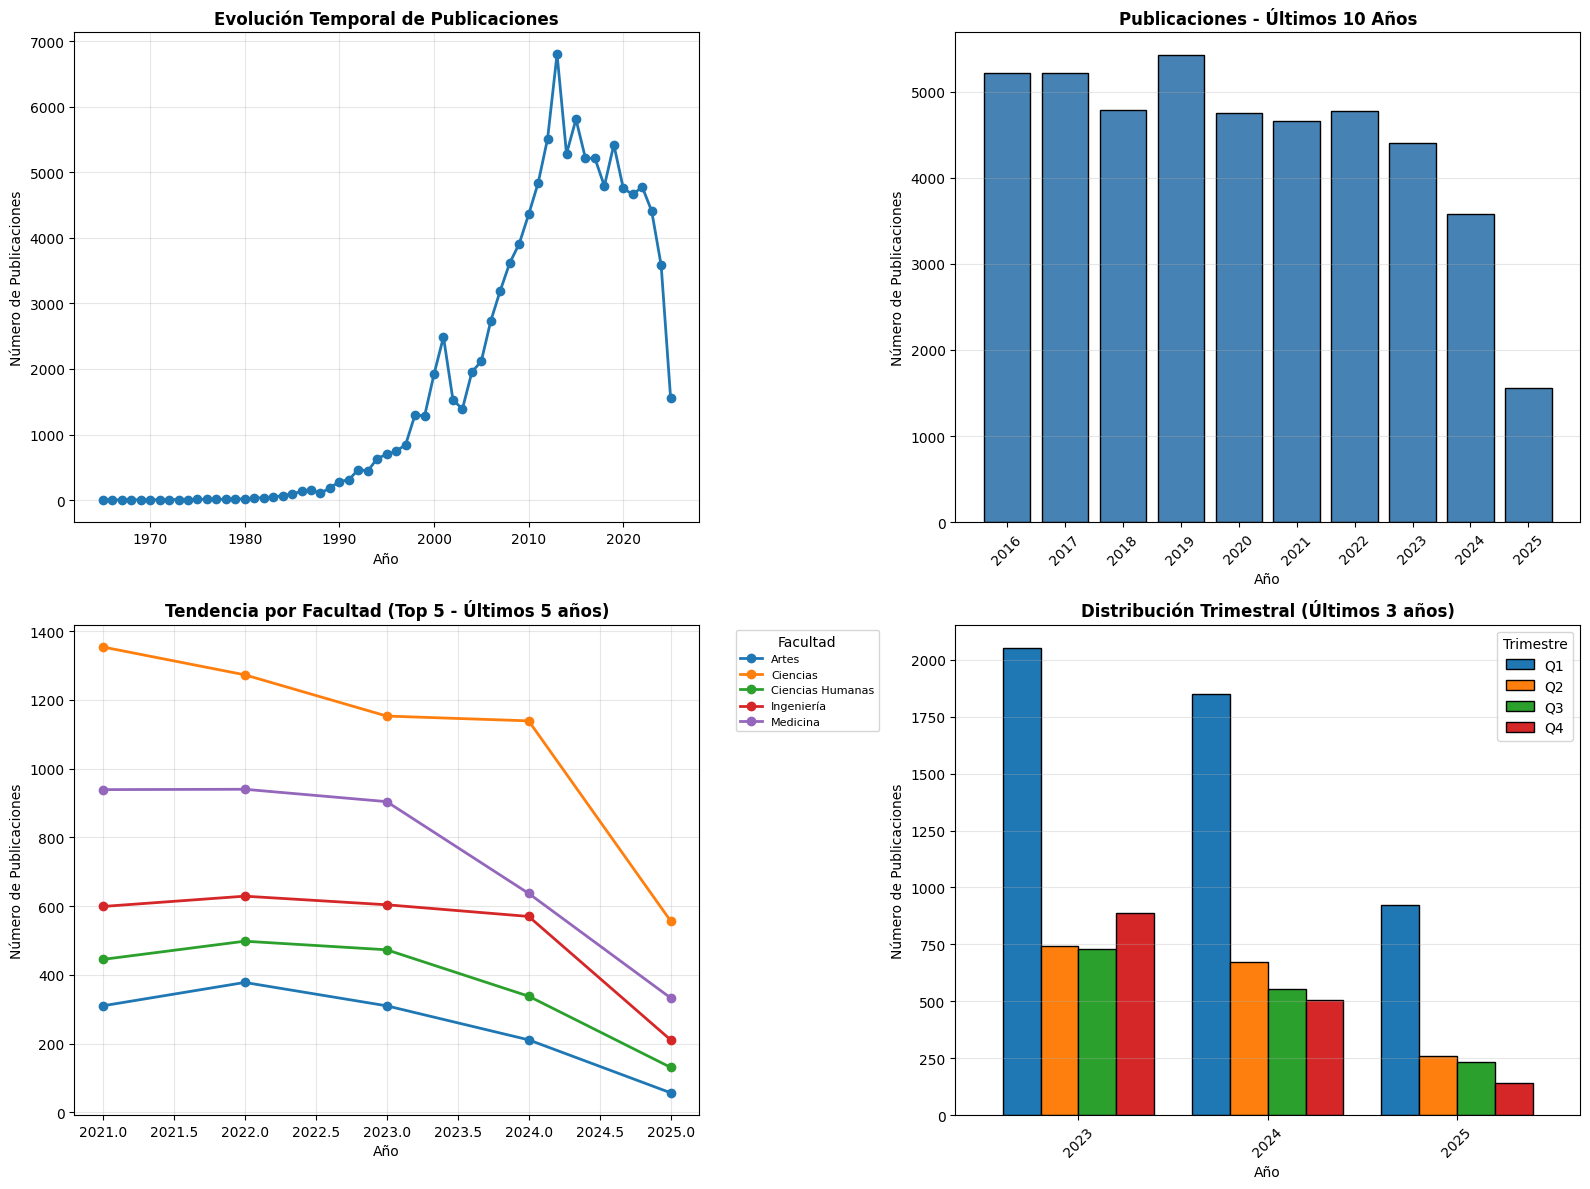


--- Estacionalidad por Mes ---


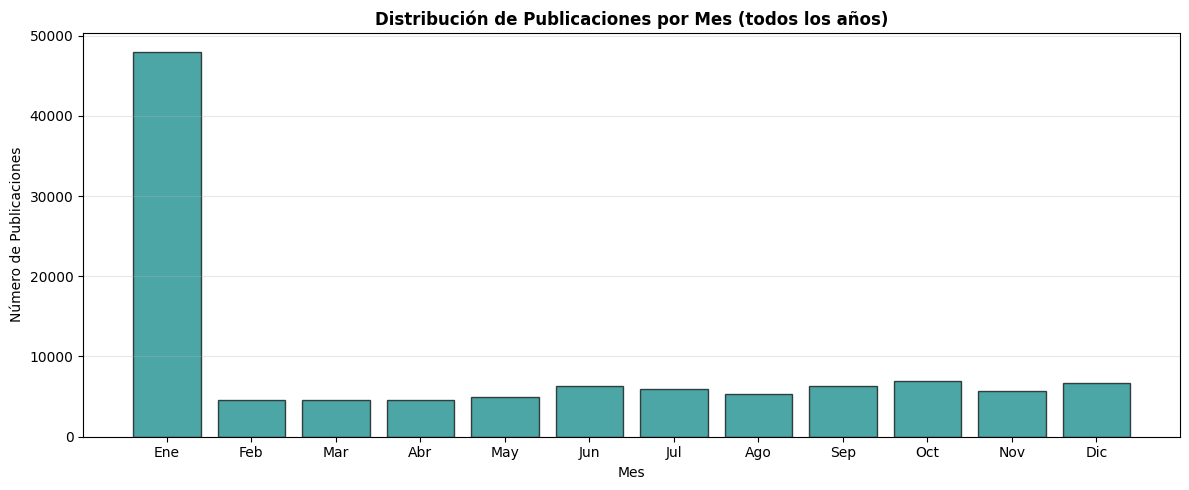


--- Tasa de Crecimiento por Facultad (últimos 5 años) ---


,min,max,count
Facultad,,,
Ciencias,2021,2025,5476
Medicina,2021,2025,3753
Ingeniería,2021,2025,2613
Ciencias Humanas,2021,2025,1885
Artes,2021,2025,1266
Ciencias Agrarias,2021,2025,914
Ciencias Económicas,2021,2025,749
Enfermería,2021,2025,742
Derecho,2021,2025,620


In [ ]:
# Análisis Temporal de Publicaciones
print("="*60)
print("ANÁLISIS TEMPORAL DE PUBLICACIONES")
print("="*60)

# Convertir fecha a datetime si no se ha hecho
if 'fecha_dt' not in locals():
    fecha_dt = pd.to_datetime(productos_bogota["Fecha"], errors="coerce", dayfirst=True)

# Agregar columnas temporales al DataFrame
productos_bogota['año'] = fecha_dt.dt.year
productos_bogota['mes'] = fecha_dt.dt.month
productos_bogota['trimestre'] = fecha_dt.dt.quarter

# Filtrar datos con fecha válida
datos_temporales = productos_bogota[productos_bogota['año'].notna()].copy()

print(f"Registros con fecha válida: {len(datos_temporales)} ({len(datos_temporales)/len(productos_bogota)*100:.1f}%)")
print(f"Rango temporal: {datos_temporales['año'].min():.0f} - {datos_temporales['año'].max():.0f}")

# 1. Producción por año
print("\n--- Producción Anual ---")
prod_anual = datos_temporales['año'].value_counts().sort_index()
display(prod_anual.tail(10).to_frame("publicaciones"))

# 2. Estadísticas por facultad y año (Top 5 facultades)
print("\n--- Producción por Facultad (últimos 5 años) ---")
top_facultades = datos_temporales['Facultad'].value_counts().head(5).index
ultimos_5_anios = datos_temporales['año'].max() - 4

facultad_anio = datos_temporales[
    (datos_temporales['Facultad'].isin(top_facultades)) &
    (datos_temporales['año'] >= ultimos_5_anios)
].groupby(['Facultad', 'año']).size().unstack(fill_value=0)

display(facultad_anio)

# 3. Tendencia de crecimiento
print("\n--- Análisis de Tendencia ---")
# Calcular crecimiento año a año
crecimiento = prod_anual.pct_change() * 100
print(f"Crecimiento promedio anual: {crecimiento.mean():.2f}%")
print(f"Año con mayor crecimiento: {crecimiento.idxmax():.0f} ({crecimiento.max():.1f}%)")
print(f"Año con mayor producción: {prod_anual.idxmax():.0f} ({prod_anual.max()} publicaciones)")

# 4. Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Serie temporal completa
axes[0, 0].plot(prod_anual.index, prod_anual.values, marker='o', linewidth=2)
axes[0, 0].set_title('Evolución Temporal de Publicaciones', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Año')
axes[0, 0].set_ylabel('Número de Publicaciones')
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Últimos 10 años (barras)
ultimos_10 = prod_anual.tail(10)
axes[0, 1].bar(ultimos_10.index.astype(str), ultimos_10.values, color='steelblue', edgecolor='black')
axes[0, 1].set_title('Publicaciones - Últimos 10 Años', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Año')
axes[0, 1].set_ylabel('Número de Publicaciones')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Gráfico 3: Tendencia por facultad (Top 5, últimos 5 años)
facultad_anio.T.plot(ax=axes[1, 0], marker='o', linewidth=2)
axes[1, 0].set_title('Tendencia por Facultad (Top 5 - Últimos 5 años)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Año')
axes[1, 0].set_ylabel('Número de Publicaciones')
axes[1, 0].legend(title='Facultad', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Distribución por trimestre (últimos 3 años)
ultimos_3_anios = datos_temporales['año'].max() - 2
datos_trimestre = datos_temporales[datos_temporales['año'] >= ultimos_3_anios]
trim_pivot = datos_trimestre.groupby(['año', 'trimestre']).size().unstack(fill_value=0)
trim_pivot.plot(kind='bar', ax=axes[1, 1], width=0.8, edgecolor='black')
axes[1, 1].set_title('Distribución Trimestral (Últimos 3 años)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('Número de Publicaciones')
axes[1, 1].legend(title='Trimestre', labels=['Q1', 'Q2', 'Q3', 'Q4'])
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 5. Análisis de estacionalidad (publicaciones por mes)
print("\n--- Estacionalidad por Mes ---")
prod_mensual = datos_temporales['mes'].value_counts().sort_index()
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(1, 13), [prod_mensual.get(i, 0) for i in range(1, 13)],
       color='teal', edgecolor='black', alpha=0.7)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)
ax.set_title('Distribución de Publicaciones por Mes (todos los años)', fontsize=12, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Número de Publicaciones')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 6. Tasa de publicación por facultad (últimos 5 años)
print("\n--- Tasa de Crecimiento por Facultad (últimos 5 años) ---")
facultades_crecimiento = datos_temporales[
    datos_temporales['año'] >= ultimos_5_anios
].groupby('Facultad')['año'].agg(['min', 'max', 'count'])

display(facultades_crecimiento.sort_values('count', ascending=False).head(10))

# Limpiar columnas temporales
productos_bogota.drop(columns=['año', 'mes', 'trimestre'], inplace=True)

## 2.5. Metadata Quality and Text Field Analysis ('Titulo original', 'Descripción original')

In [ ]:
# Análisis de columnas de texto (Titulo original y Descripción)
print("="*60)
print("ANÁLISIS DE COLUMNAS DE TEXTO")
print("="*60)

# Títulos
productos_bogota['titulo_length'] = productos_bogota['Título original'].fillna('').astype(str).str.len()
display(pd.DataFrame({
    'columna': ['Título original'],
    'total': [len(productos_bogota)],
    'no_nulos': [productos_bogota['Título original'].notna().sum()],
    'vacios': [(productos_bogota['Título original'].fillna('').astype(str).str.strip() == '').sum()],
    'longitud_promedio': [productos_bogota['titulo_length'].mean()],
    'longitud_mediana': [productos_bogota['titulo_length'].median()],
    'longitud_min': [productos_bogota['titulo_length'].min()],
    'longitud_max': [productos_bogota['titulo_length'].max()]
}))

# Descripción/Abstracts
productos_bogota['desc_length'] = productos_bogota['Descripción original'].fillna('').astype(str).str.len()
desc_no_nulos = productos_bogota['Descripción original'].notna()
desc_cortos = (productos_bogota['desc_length'] > 0) & (productos_bogota['desc_length'] < 50)

display(pd.DataFrame({
    'columna': ['Descripción original'],
    'total': [len(productos_bogota)],
    'no_nulos': [desc_no_nulos.sum()],
    'vacios': [(productos_bogota['desc_length'] == 0).sum()],
    'muy_cortos (<50 chars)': [desc_cortos.sum()],
    'longitud_promedio': [productos_bogota.loc[desc_no_nulos, 'desc_length'].mean()],
    'longitud_mediana': [productos_bogota.loc[desc_no_nulos, 'desc_length'].median()],
    'longitud_min': [productos_bogota.loc[desc_no_nulos, 'desc_length'].min()],
    'longitud_max': [productos_bogota.loc[desc_no_nulos, 'desc_length'].max()]
}))

# Limpiar columnas temporales
productos_bogota.drop(columns=['titulo_length', 'desc_length'], inplace=True)

# Mostrar ejemplos de abstracts muy cortos
if desc_cortos.sum() > 0:
    print("\nEjemplos de descripciones muy cortas:")
    display(productos_bogota.loc[desc_cortos, ['Título original', 'Descripción original']].head(5))

ANÁLISIS DE COLUMNAS DE TEXTO


,columna,total,no_nulos,vacios,longitud_promedio,longitud_mediana,longitud_min,longitud_max
0,Título original,109836,109835,1,95.878319,92.0,0,978


,columna,total,no_nulos,vacios,muy_cortos (<50 chars),longitud_promedio,longitud_mediana,longitud_min,longitud_max
0,Descripción original,109836,69928,39908,7023,1349.212747,1191.0,1,23677



Ejemplos de descripciones muy cortas:


,Título original,Descripción original
81,EFECTO DE LA VARIABILIDAD CLIMÁTICA EN PRODUCC...,No Reportado
90,VULNERABILIDAD DE ESTRUCTURAS DE CONCRETO REFO...,No Reportado
91,DISEÑO DE SISTEMA ELECTRÓNICO PARA EL MONITORE...,No Reportado
92,TÉCNICAS PARA IDENTIFICAR FALLAS ELÉCTRICAS EN...,No Reportado
94,RESISTENCIA A LA CORROSIÓN DEL RECUBRIMIENTO D...,No Reportado


In [ ]:
print("="*60)
print("ANÁLISIS DE CALIDAD DE DATOS - VALORES FALTANTES Y CONVENCIONES")
print("="*60)

# Check each column for conventions
columnas_revisar = ['Título original', 'Descripción original', 'Idioma',
                    'Fuente', 'Tipo', 'Revista / Conferencia', 'DOI', 'ISBN', 'ISSN']

resumen_calidad = []
for col in columnas_revisar:
    if col not in productos_bogota.columns:
        continue
    nulos_reales = productos_bogota[col].isna().sum()
    nulos_convencion = productos_bogota[col].apply(es_valor_nulo_convencion).sum() - nulos_reales
    vacios = (productos_bogota[col].fillna('').astype(str).str.strip() == '').sum() - nulos_reales
    resumen_calidad.append({
        'Columna': col,
        'NaN reales': nulos_reales,
        'Vacíos ("")': vacios,
        'Convenciones (e.g. No Reportado)': nulos_convencion,
        'Total efectivamente nulos': nulos_reales + vacios + nulos_convencion,
        '% nulo efectivo': round((nulos_reales + vacios + nulos_convencion) / len(productos_bogota) * 100, 2),
        'Únicos válidos': productos_bogota[col].dropna().nunique()
    })

resumen_calidad_df = pd.DataFrame(resumen_calidad)
display(resumen_calidad_df)

# Rows with empty title
sin_titulo = productos_bogota[
    productos_bogota['Título original'].fillna('').astype(str).str.strip() == ''
]
print(f"\nFilas sin título: {len(sin_titulo)}")
display(sin_titulo[['Tipo', 'Fuente', 'Facultad', 'Descripción original']].head(10))

ANÁLISIS DE CALIDAD DE DATOS - VALORES FALTANTES Y CONVENCIONES


,Columna,NaN reales,"Vacíos ("""")",Convenciones (e.g. No Reportado),Total efectivamente nulos,% nulo efectivo,Únicos válidos
0,Título original,1,0,0,1,0.00,104658
1,Descripción original,39908,0,5849,45757,41.66,59491
2,Idioma,7733,0,0,7733,7.04,30
3,Fuente,0,0,0,0,0.00,12
4,Tipo,0,0,0,0,0.00,30
5,Revista / Conferencia,41852,0,0,41852,38.10,13456
6,ISBN,100105,0,0,100105,91.14,6073
7,ISSN,66136,0,0,66136,60.21,9587



Filas sin título: 1


,Tipo,Fuente,Facultad,Descripción original
49067,Proyecto,HERMES,Ciencias Humanas,NaN


## 2.6 Linguistic Metadata Analysis ('Idioma')

ANÁLISIS DETALLADO DE IDIOMA

Distribución completa de idiomas:


,frecuencia,porcentaje
Idioma,,
Español,60001,54.63
Inglés,37254,33.92
NaN,7733,7.04
Portugués,1119,1.02
Galicia,1110,1.01
Indonesio,632,0.58
Francés,454,0.41
Italiano,432,0.39
Alemán,374,0.34



Registros sin idioma especificado: 7733
De estos, tienen descripción: 410

Idioma por Facultad (top 8 idiomas):


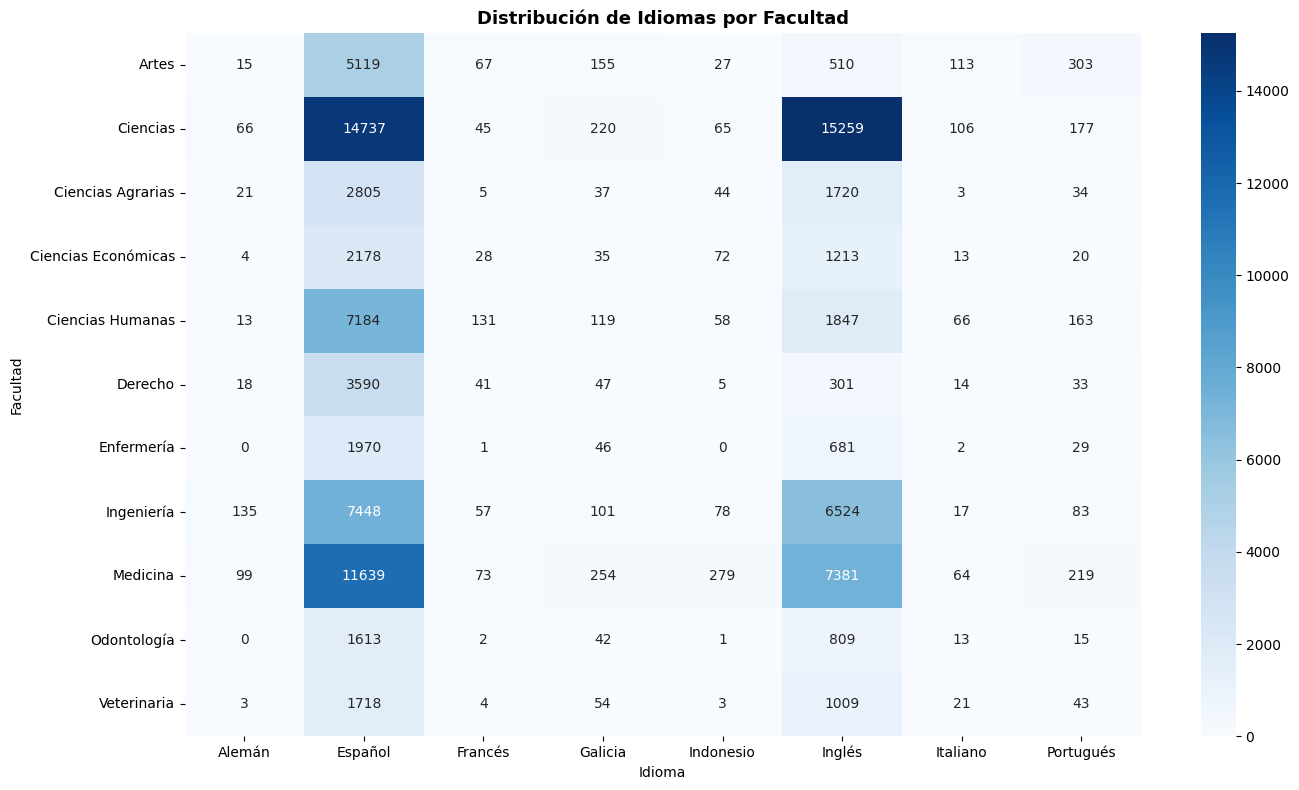


Idioma por Tipo de producción (top 8 idiomas):


Idioma,Alemán,Español,Francés,Galicia,Indonesio,Inglés,Italiano,Portugués
Tipo,,,,,,,,
Apoyo a la investigación,0,0,0,0,0,12,0,0
Artículo de conferencia,60,1947,8,17,107,3687,10,31
Artículo de revista,167,12504,83,189,322,25863,123,197
Capítulo de libro,22,5140,97,158,28,1056,72,73
Colección científica,1,113,0,6,0,3,0,2
Comentario,0,0,0,0,0,3,1,0
Datos,5,17,7,0,1,76,1,3
Desarrollo de software,10,85,1,4,3,6,1,35
Editorial,30,103,6,1,99,305,0,2



Registros sin idioma: 7733
Inferencia heurística para registros sin idioma:


,conteo
Título original,
Español (inferido),4165
Inglés (inferido),2030
Indeterminado,1538


In [ ]:
print("="*60)
print("ANÁLISIS DETALLADO DE IDIOMA")
print("="*60)

print("\nDistribución completa de idiomas:")
idioma_counts = productos_bogota['Idioma'].value_counts(dropna=False)
display(idioma_counts.to_frame("frecuencia").assign(
    porcentaje=lambda df: (df['frecuencia'] / len(productos_bogota) * 100).round(2)
))

productos_con_desc = productos_bogota['Descripción original'].notna()
productos_sin_idioma = productos_bogota['Idioma'].isna()

print(f"\nRegistros sin idioma especificado: {productos_sin_idioma.sum()}")
print(f"De estos, tienen descripción: {(productos_sin_idioma & productos_con_desc).sum()}")

# Language vs Faculty heatmap
print("\nIdioma por Facultad (top 8 idiomas):")
top_idiomas = productos_bogota['Idioma'].value_counts().head(8).index
idioma_facultad = productos_bogota[
    productos_bogota['Idioma'].isin(top_idiomas)
].groupby(['Facultad', 'Idioma']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(idioma_facultad, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Distribución de Idiomas por Facultad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Language vs Tipo
print("\nIdioma por Tipo de producción (top 8 idiomas):")
idioma_tipo = productos_bogota[
    productos_bogota['Idioma'].isin(top_idiomas)
].groupby(['Tipo', 'Idioma']).size().unstack(fill_value=0)
display(idioma_tipo)

sin_idioma_mask = productos_bogota['Idioma'].apply(es_valor_nulo_convencion)
print(f"\nRegistros sin idioma: {sin_idioma_mask.sum()}")
idiomas_inferidos = productos_bogota.loc[sin_idioma_mask, 'Título original'].apply(inferir_idioma_heuristico)
print("Inferencia heurística para registros sin idioma:")
display(idiomas_inferidos.value_counts().to_frame("conteo"))

## 2.7. Categorical Structure Analysis ('Tipo', 'Fuente', 'Facultad', 'Revista / Conferencia')

ANÁLISIS DE COLUMNAS CATEGÓRICAS

--- Tipo ---
Categorías únicas: 30
Top 10:


,frecuencia
Tipo,
Artículo de revista,41706
Tesis Maestría,17660
Ponencias en eventos especializados,10422
Proyecto,10152
Capítulo de libro,7767
Libro,6071
Artículo de conferencia,5979
Tesis Doctorado,2408
Tesis Especialización,1561


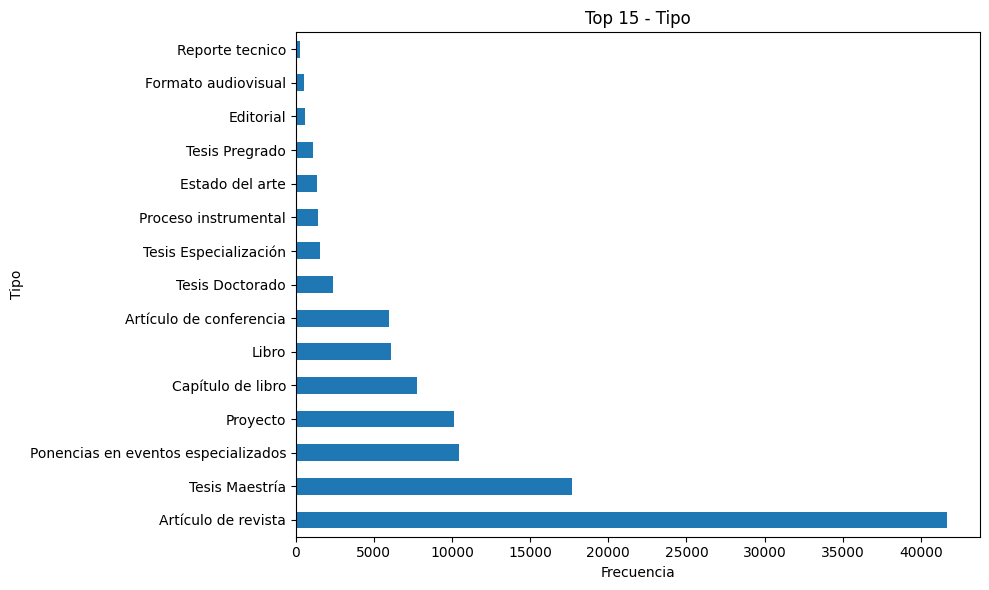


--- Fuente ---
Categorías únicas: 12
Top 10:


,frecuencia
Fuente,
SARA,49040
SCOPUS,23756
RepositorioUNAL,12287
HERMES,10152
CURADURIA,4359
RG,3977
RevistasUNAL,2143
WEB OF SCIENCE,2013
BibliotecasUNAL,1169


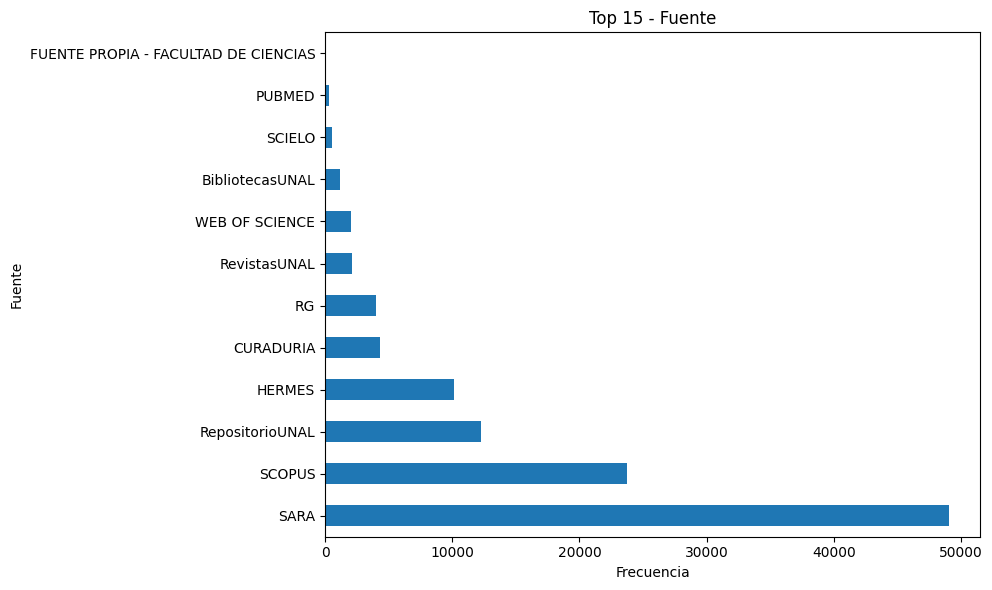


--- Facultad ---
Categorías únicas: 11
Top 10:


,frecuencia
Facultad,
Ciencias,33701
Medicina,21115
Ingeniería,15228
Ciencias Humanas,10415
Artes,7640
Ciencias Agrarias,4884
Derecho,4268
Ciencias Económicas,3758
Veterinaria,3256


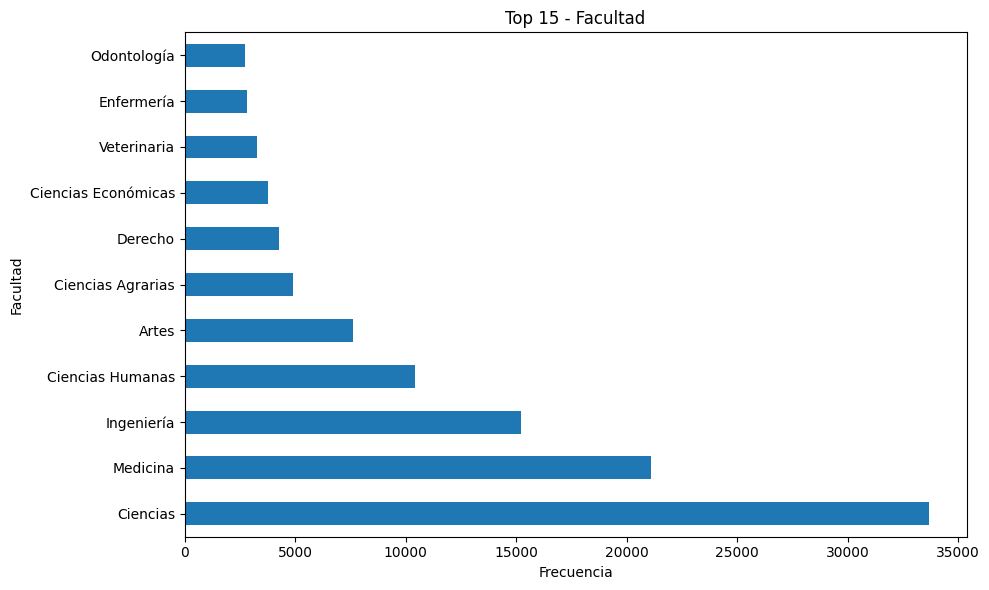


--- Revista / Conferencia ---
Categorías únicas: 13457
Top 10:


,frecuencia
Revista / Conferencia,
NaN,41852
Universidad Nacional de Colombia,12150
Revista de la Facultad de Medicína,1005
Revista Colombiana de Física,666
Biomédica,577
Agronomía Colombiana,511
Ingeniería e Investigación,493
Revista de Salud Pública,487
The Journal of High Energy Physics,444


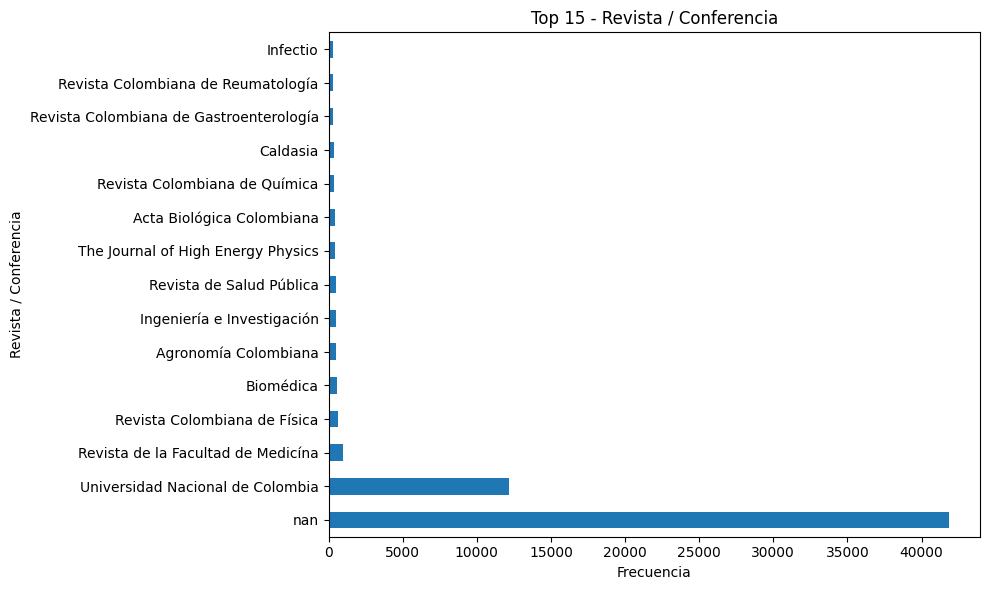

In [ ]:
# Análisis de columnas categóricas importantes
print("="*60)
print("ANÁLISIS DE COLUMNAS CATEGÓRICAS")
print("="*60)

columnas_categoricas = ['Tipo', 'Fuente', 'Facultad', 'Revista / Conferencia']

for col in columnas_categoricas:
    print(f"\n--- {col} ---")
    conteo = productos_bogota[col].value_counts(dropna=False)
    print(f"Categorías únicas: {productos_bogota[col].nunique(dropna=False)}")
    print(f"Top 10:")
    display(conteo.head(10).to_frame("frecuencia"))

    # Visualización
    fig, ax = plt.subplots(figsize=(10, 6))
    conteo.head(15).plot(kind='barh', ax=ax)
    ax.set_title(f'Top 15 - {col}')
    ax.set_xlabel('Frecuencia')
    plt.tight_layout()
    plt.show()

RELACIÓN: FUENTE x FACULTAD x TIPO
Top fuentes por facultad:


Facultad,Artes,Ciencias,Ciencias Agrarias,Ciencias Económicas,Ciencias Humanas,Derecho,Enfermería,Ingeniería,Medicina,Odontología,Veterinaria
Fuente,,,,,,,,,,,
BibliotecasUNAL,111,328,45,51,134,64,46,126,174,53,37
CURADURIA,1,40,515,4,10,0,4,12,3756,15,2
HERMES,808,3422,508,304,996,507,209,1497,1182,371,348
RG,2,143,724,18,22,277,6,1133,1643,6,3
RepositorioUNAL,974,3350,433,823,1121,619,294,2227,2077,185,184
RevistasUNAL,147,753,45,102,455,130,51,166,189,66,39
SARA,5291,14114,1581,1860,6250,2475,1619,5678,6642,1509,2021
SCIELO,19,204,23,21,48,7,35,51,129,18,8
SCOPUS,245,10602,929,439,1089,86,455,4016,4895,442,558



Top fuentes por tipo de producción:


Tipo,Artículo de conferencia,Artículo de revista,Capítulo de libro,Colección científica,Datos,Desarrollo de software,Editorial,Estado del arte,Formato audiovisual,Libro,...,Ponencias en eventos especializados,Posters presentados,Preimpresión,Proceso instrumental,Proyecto,Reporte tecnico,Tesis Doctorado,Tesis Especialización,Tesis Maestría,Tesis Pregrado
Fuente,,,,,,,,,,,,,,,,,,,,,
BibliotecasUNAL,0,0,0,0,0,0,0,0,0,304,...,0,0,0,0,0,0,25,95,187,558
CURADURIA,1249,1662,681,0,0,0,0,0,0,549,...,0,0,0,0,0,210,0,0,0,0
HERMES,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,10152,0,0,0,0,0
RG,745,2425,246,0,144,1,0,0,0,158,...,0,108,44,0,0,48,0,0,0,0
RepositorioUNAL,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1159,906,9717,505
RevistasUNAL,0,2143,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SARA,1246,13946,6470,90,0,197,0,0,495,5036,...,10422,0,0,1425,0,0,1224,560,7756,10
SCIELO,0,563,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SCOPUS,2739,18986,370,0,0,0,480,1156,0,24,...,0,0,1,0,0,0,0,0,0,0


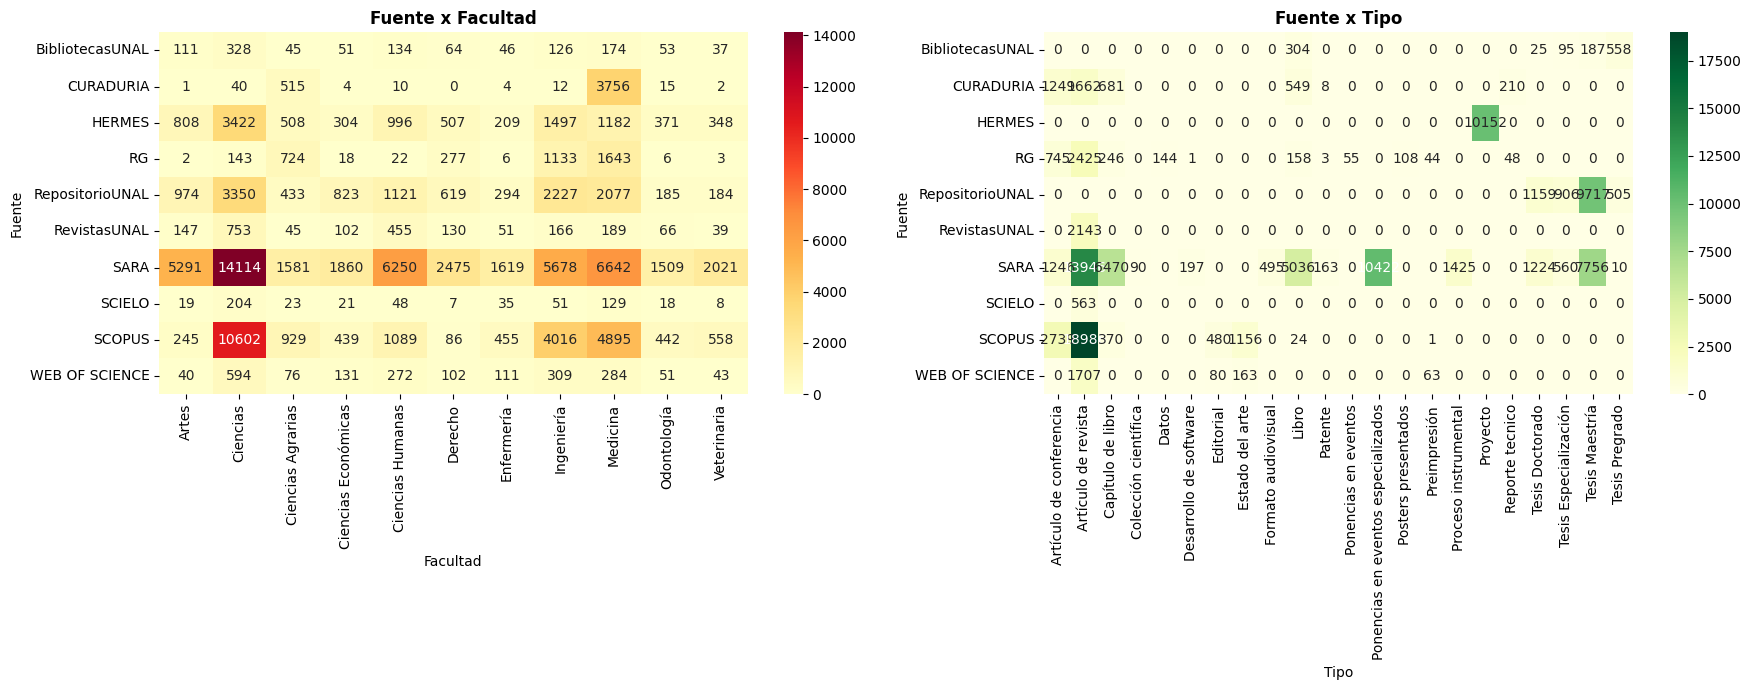

In [ ]:
print("="*60)
print("RELACIÓN: FUENTE x FACULTAD x TIPO")
print("="*60)

# Fuente vs Facultad
top_fuentes = productos_bogota['Fuente'].value_counts().head(10).index
fuente_facultad = productos_bogota[
    productos_bogota['Fuente'].isin(top_fuentes)
].groupby(['Fuente', 'Facultad']).size().unstack(fill_value=0)

print("Top fuentes por facultad:")
display(fuente_facultad)

# Fuente vs Tipo
fuente_tipo = productos_bogota[
    productos_bogota['Fuente'].isin(top_fuentes)
].groupby(['Fuente', 'Tipo']).size().unstack(fill_value=0)

print("\nTop fuentes por tipo de producción:")
display(fuente_tipo)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(fuente_facultad, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Fuente x Facultad', fontsize=12, fontweight='bold')
sns.heatmap(fuente_tipo, annot=True, fmt='d', cmap='YlGn', ax=axes[1])
axes[1].set_title('Fuente x Tipo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.8. Authorship Structure Analysis ('Coautores')

ANÁLISIS DE COAUTORES


count    109836.000000
mean         26.984067
std         237.097728
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max        4289.000000
Name: num_coautores, dtype: float64

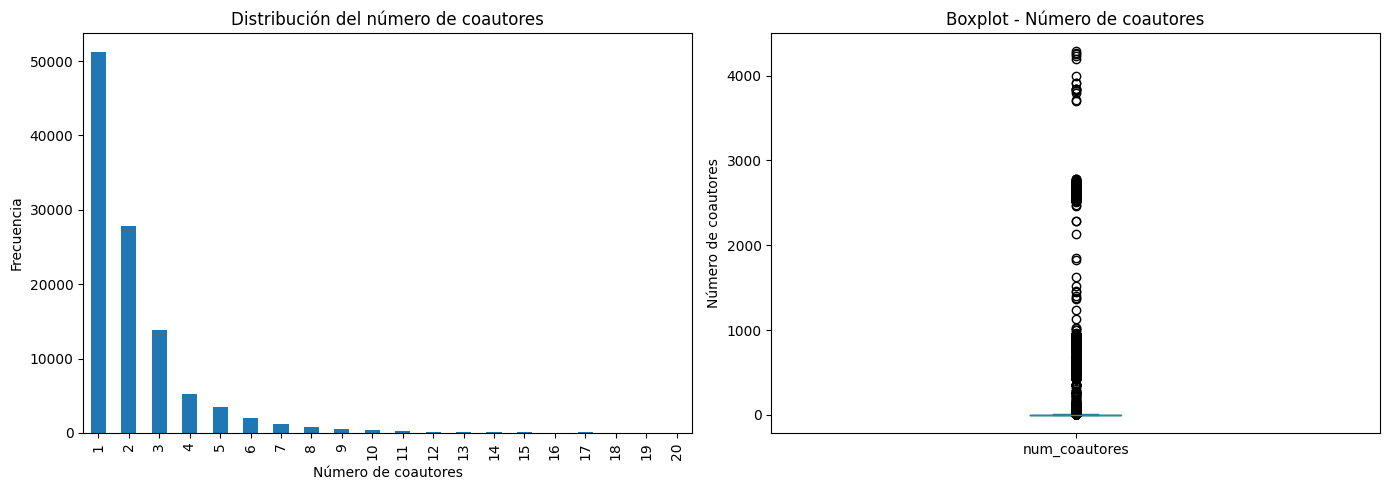


Total de nombres únicos de coautores: 99589


In [ ]:
# Análisis de Coautores
print("="*60)
print("ANÁLISIS DE COAUTORES")
print("="*60)

productos_bogota['num_coautores'] = productos_bogota['Coautores'].apply(contar_coautores)
productos_bogota.loc[productos_bogota['Coautores'].isna(), 'num_coautores'] = 0

display(productos_bogota['num_coautores'].describe())

# Distribución del número de coautores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

productos_bogota['num_coautores'].value_counts().sort_index().head(20).plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribución del número de coautores')
axes[0].set_xlabel('Número de coautores')
axes[0].set_ylabel('Frecuencia')

productos_bogota['num_coautores'].plot(kind='box', ax=axes[1])
axes[1].set_title('Boxplot - Número de coautores')
axes[1].set_ylabel('Número de coautores')

plt.tight_layout()
plt.show()

todos_coautores = []
for coautores in productos_bogota['Coautores']:
    todos_coautores.extend(extraer_coautores(coautores))

coautores_counter = Counter(todos_coautores)
print(f"\nTotal de nombres únicos de coautores: {len(coautores_counter)}")

In [ ]:
# Antes del análisis de co-autoría, verificar anomalías
print("Verificando anomalías en coautores...")
num_coautores_list = productos_bogota['Coautores'].apply(
    lambda x: len(extraer_coautores(x))
)
print(num_coautores_list.describe())
print(f"Papers con >100 coautores: {(num_coautores_list > 100).sum()}")
print(f"Papers con >50 coautores: {(num_coautores_list > 50).sum()}")

Verificando anomalías en coautores...
count    109836.000000
mean         26.984067
std         237.097728
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max        4289.000000
Name: Coautores, dtype: float64
Papers con >100 coautores: 1591
Papers con >50 coautores: 1702


INSPECCIÓN DE FILAS CON MUCHOS COAUTORES
Filas con más de 50 coautores: 1702


,Título original,Descripción original,Revista / Conferencia,Coautores,Doi,ISBN,ISSN,Citaciones,Idioma,Fecha,Tipo,Fuente,Enlace,Facultad,num_coautores
66269,Combination of the W boson polarization measur...,The combination of measurements of the W boson...,The Journal of High Energy Physics,"Sandoval Usme Carlos Eduardo, Paredes Hernande...",10.1007/JHEP08(2020)051,NaN,"10298479, 11266708",16.0,Inglés,08/01/2020,Artículo de revista,SCOPUS,http://dx.doi.org/10.1007/JHEP08(2020)051 - ...,Ciencias,4289
68028,Combinations of single-top-quark production cr...,This paper presents the combinations of single...,The Journal of High Energy Physics,"Sandoval Usme Carlos Eduardo, Paredes Hernande...",10.1007/JHEP05(2019)088,NaN,"10298479, 11266708",21.0,Inglés,05/01/2019,Artículo de revista,SCOPUS,http://dx.doi.org/10.1007/JHEP05(2019)088 - ...,Ciencias,4267
69944,Combination of inclusive and differential tt¯ ...,This paper presents combinations of inclusive ...,The Journal of High Energy Physics,"Sandoval Usme Carlos Eduardo, Castañeda Acero ...",10.1007/JHEP04(2018)033,NaN,"10298479, 11266708",10.0,Inglés,01/01/2018,Artículo de revista,SCOPUS,http://dx.doi.org/10.1007/JHEP04(2018)033 - ...,Ciencias,4259
74338,Combined Measurement of the Higgs Boson Mass i...,A measurement of the Higgs boson mass is prese...,Physical Review Letters,"Sandoval Usme Carlos Eduardo, Martinez Paez Jo...",10.1103/PhysRevLett.114.191803,NaN,"00319007, 10797114",1050.0,Inglés,14/05/2015,Artículo de revista,SCOPUS,http://dx.doi.org/10.1103/PhysRevLett.114.1918...,Ciencias,4229
72861,Measurements of the Higgs boson production and...,Combined ATLAS and CMS measurements of the Hig...,The Journal of High Energy Physics,"Sandoval Usme Carlos Eduardo, Martinez Paez Jo...",10.1007/JHEP08(2016)045,NaN,10298479,706.0,Inglés,08/01/2016,Artículo de revista,SCOPUS,http://dx.doi.org/10.1007/JHEP08(2016)045 - ...,Ciencias,4197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14418,"Colombia, 1997-2005 Estudio clínico y epidemio...",Inroduction. A national survey on cryptococcos...,Biomédica,"Álvarez Moreno Carlos Arturo, Rivas Pinedo Jul...",10.7705/biomedica.v27i1.236,NaN,01204157,49.0,Inglés,01/01/2007,Artículo de revista,SCOPUS,http://dx.doi.org/10.7705/biomedica.v27i1.236 ...,Ingeniería,52
134793,"Colombia, 1997-2005 Estudio clínico y epidemio...",Inroduction. A national survey on cryptococcos...,Biomédica,"Álvarez Moreno Carlos Arturo, Rivas Pinedo Jul...",10.7705/biomedica.v27i1.236,NaN,01204157,49.0,Inglés,01/01/2007,Artículo de revista,SCOPUS,http://dx.doi.org/10.7705/biomedica.v27i1.236 ...,Medicina,52
89813,"Colombia, 1997-2005 Estudio clínico y epidemio...",Inroduction. A national survey on cryptococcos...,Biomédica,"Álvarez Moreno Carlos Arturo, Rivas Pinedo Jul...",10.7705/biomedica.v27i1.236,NaN,01204157,49.0,Inglés,01/01/2007,Artículo de revista,SCOPUS,http://dx.doi.org/10.7705/biomedica.v27i1.236 ...,Ciencias,52
113125,"Colombia, 1997-2005 Estudio clínico y epidemio...",Inroduction. A national survey on cryptococcos...,Biomédica,"Álvarez Moreno Carlos Arturo, Rivas Pinedo Jul...",10.7705/biomedica.v27i1.236,NaN,01204157,49.0,Inglés,01/01/2007,Artículo de revista,SCOPUS,http://dx.doi.org/10.7705/biomedica.v27i1.236 ...,Enfermería,52


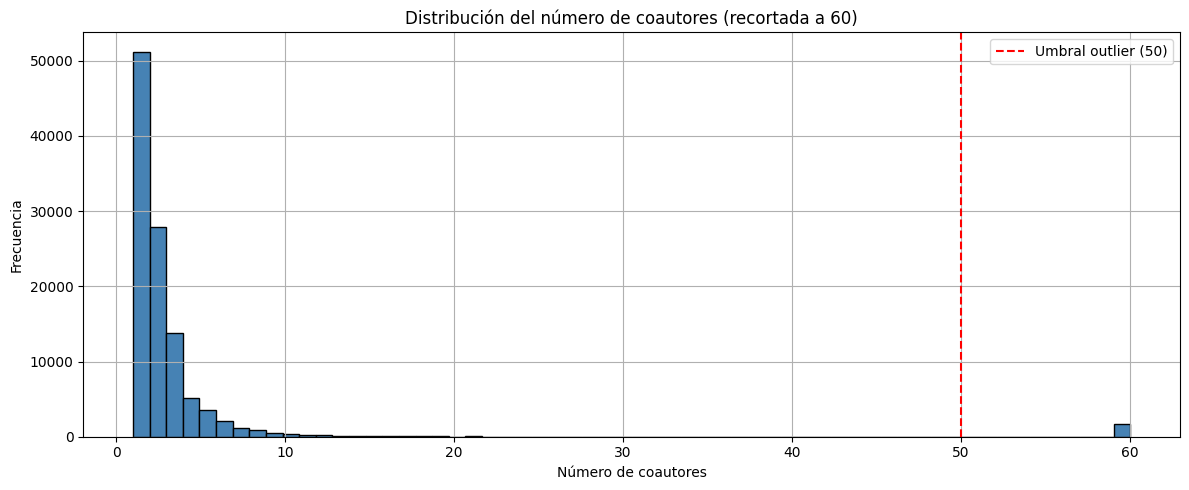


Coautores promedio por tipo de producción:


,mean,median,max,count
Tipo,,,,
Artículo de revista,67.533952,2.0,4289,41706
Estado del arte,15.893633,3.0,2641,1335
Estudio multicéntrico,11.000000,11.0,11,1
Estudio observacional,11.000000,11.0,14,2
Editorial,4.088028,1.0,923,568
Reporte de caso,4.000000,3.0,8,9
Errata,3.500000,2.0,10,8
Comentario,3.500000,3.0,5,4
Artículo de conferencia,3.445392,2.0,550,5979


In [ ]:
# --- Inspect high-coauthor rows ---
print("="*60)
print("INSPECCIÓN DE FILAS CON MUCHOS COAUTORES")
print("="*60)

umbral_outlier = 50  # adjust as needed
outliers_coautores = productos_bogota[productos_bogota['num_coautores'] > umbral_outlier]

print(f"Filas con más de {umbral_outlier} coautores: {len(outliers_coautores)}")
display(outliers_coautores.sort_values('num_coautores', ascending=False))

# Distribution to understand where outliers begin
fig, ax = plt.subplots(figsize=(12, 5))
productos_bogota['num_coautores'].clip(upper=60).hist(bins=60, ax=ax, edgecolor='black', color='steelblue')
ax.axvline(x=umbral_outlier, color='red', linestyle='--', label=f'Umbral outlier ({umbral_outlier})')
ax.set_title('Distribución del número de coautores (recortada a 60)')
ax.set_xlabel('Número de coautores')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

# Breakdown by Tipo
print("\nCoautores promedio por tipo de producción:")
display(productos_bogota.groupby('Tipo')['num_coautores'].agg(['mean','median','max','count']).sort_values('mean', ascending=False))

ANÁLISIS COMPLEMENTARIO COAUTORES x TIPO
Coautores por Tipo de producción:


,mean,median,max,count
Tipo,,,,
Artículo de revista,67.533952,2.0,4289,41706
Estado del arte,15.893633,3.0,2641,1335
Estudio multicéntrico,11.000000,11.0,11,1
Estudio observacional,11.000000,11.0,14,2
Editorial,4.088028,1.0,923,568
Reporte de caso,4.000000,3.0,8,9
Errata,3.500000,2.0,10,8
Comentario,3.500000,3.0,5,4
Artículo de conferencia,3.445392,2.0,550,5979


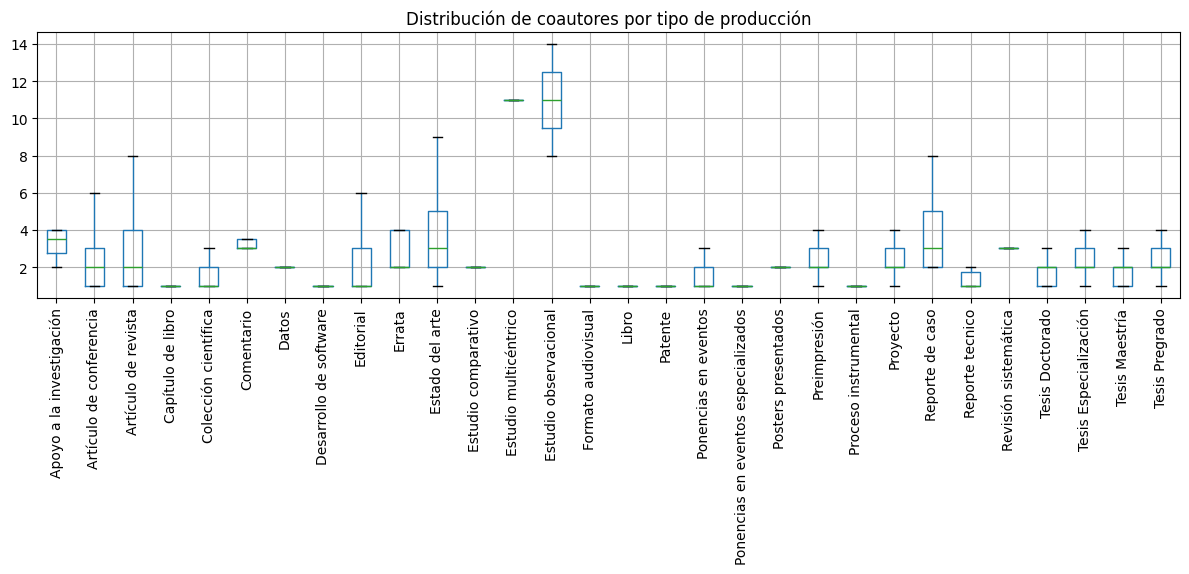

In [ ]:
print("="*60)
print("ANÁLISIS COMPLEMENTARIO COAUTORES x TIPO")
print("="*60)

# --- A. Correlation between num_coautores and Tipo ---
print("Coautores por Tipo de producción:")
coautores_tipo = productos_bogota.groupby('Tipo')['num_coautores'].agg(
    ['mean', 'median', 'max', 'count']
).sort_values('mean', ascending=False)
display(coautores_tipo)

fig, ax = plt.subplots(figsize=(12, 6))
productos_bogota.boxplot(column='num_coautores', by='Tipo', ax=ax,
                          showfliers=False, rot=90)
ax.set_title('Distribución de coautores por tipo de producción')
ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 2.9. Author frequency

ANÁLISIS DE DISTRIBUCIÓN POR AUTOR
Analizando distribución de autores desde la columna 'Coautores'...
Total de autores únicos: 99589

Estadísticas de producciones por autor:


count    99589.000000
mean        29.760536
std        143.129150
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       6585.000000
Name: count, dtype: float64


Top 20 autores más frecuentes:


,producciones
Chen C.,6585
Lee S.C.,5898
Cerqueira A.S.,5082
Seixas J.M.,4868
Parker M.A.,4808
Martin V.J.,4346
De Salvo A.,4036
Barr A.J.,3879
Chapman J.D.,3878
Hawkes C.M.,3739



--- Problema de Long Tail ---
Autores con 1 producción: 54568 (54.8%)
Autores con 2-5 producciones: 28823 (28.9%)
Autores con 6-10 producciones: 6219 (6.2%)
Autores con >10 producciones: 9979 (10.0%)


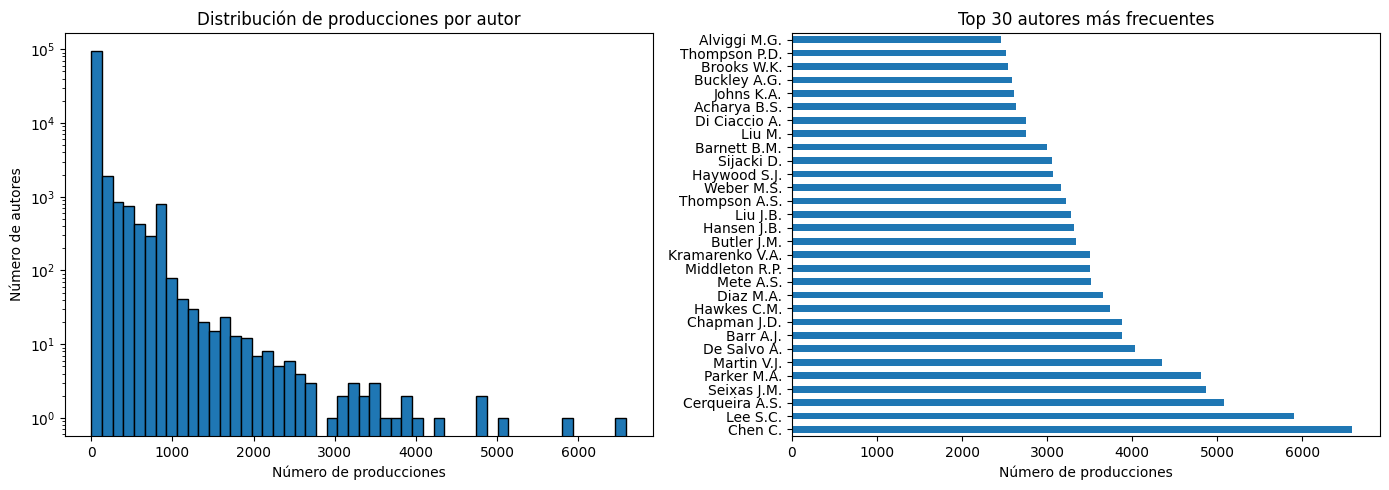

In [ ]:
# Distribución por Profesor/Autor principal
print("="*60)
print("ANÁLISIS DE DISTRIBUCIÓN POR AUTOR")
print("="*60)

# Usar la columna Coautores que ya contiene todos los autores
print("Analizando distribución de autores desde la columna 'Coautores'...")

autor_counts = pd.Series(todos_coautores).value_counts()

print(f"Total de autores únicos: {len(autor_counts)}")
print(f"\nEstadísticas de producciones por autor:")
display(autor_counts.describe())

print(f"\nTop 20 autores más frecuentes:")
display(autor_counts.head(20).to_frame("producciones"))

# Análisis Long Tail
autores_con_1 = (autor_counts == 1).sum()
autores_con_2_5 = ((autor_counts >= 2) & (autor_counts <= 5)).sum()
autores_con_6_10 = ((autor_counts >= 6) & (autor_counts <= 10)).sum()
autores_con_mas_10 = (autor_counts > 10).sum()

print("\n--- Problema de Long Tail ---")
print(f"Autores con 1 producción: {autores_con_1} ({autores_con_1/len(autor_counts)*100:.1f}%)")
print(f"Autores con 2-5 producciones: {autores_con_2_5} ({autores_con_2_5/len(autor_counts)*100:.1f}%)")
print(f"Autores con 6-10 producciones: {autores_con_6_10} ({autores_con_6_10/len(autor_counts)*100:.1f}%)")
print(f"Autores con >10 producciones: {autores_con_mas_10} ({autores_con_mas_10/len(autor_counts)*100:.1f}%)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(autor_counts, bins=50, edgecolor='black')
axes[0].set_title('Distribución de producciones por autor')
axes[0].set_xlabel('Número de producciones')
axes[0].set_ylabel('Número de autores')
axes[0].set_yscale('log')

# Top 30 autores
autor_counts.head(30).plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 30 autores más frecuentes')
axes[1].set_xlabel('Número de producciones')

plt.tight_layout()
plt.show()

## 2.10. Name disambiguation

In [ ]:
# Desambiguación de nombres - Detectar variaciones
print("="*60)
print("DETECCIÓN DE NOMBRES SIMILARES (Desambiguación)")
print("="*60)

# Analizar coautores únicos
coautores_unicos = list(set(todos_coautores))
coautores_normalizados = {nombre: normalizar_nombre(nombre) for nombre in coautores_unicos}

apellidos_dict = {}
for nombre_orig, nombre_norm in coautores_normalizados.items():
    apellido = extraer_apellido(nombre_norm)
    if apellido not in apellidos_dict:
        apellidos_dict[apellido] = []
    apellidos_dict[apellido].append(nombre_orig)

# Encontrar apellidos con múltiples variaciones
problemas_potenciales = {ap: nombres for ap, nombres in apellidos_dict.items() if len(nombres) > 1}
print(f"\nApellidos con posibles variaciones: {len(problemas_potenciales)}")

if len(problemas_potenciales) > 0:
    print("\nEjemplos de posibles duplicados (Top 20):")
    for i, (apellido, nombres) in enumerate(list(problemas_potenciales.items())[:20], 1):
        if len(nombres) <= 5:  # Mostrar solo si no son demasiados
            print(f"{i}. {apellido}: {nombres}")

DETECCIÓN DE NOMBRES SIMILARES (Desambiguación)

Apellidos con posibles variaciones: 7015

Ejemplos de posibles duplicados (Top 20):
1. neufeld: ['J. Neufeld', 'Vic Neufeld', 'Neufeld']
12. iversen: ['P. O. Iversen', 'H. K. Iversen', 'L. H. Iversen', 'Colleen M. Iversen']
20. belie: ['O. Belie', 'N. De Belie']


## 2.11. Co-authorship network

In [ ]:
# Análisis de Co-autoría (Grafo básico)
print("="*60)
print("ANÁLISIS DE CO-AUTORÍA")
print("="*60)

# Crear pares de co-autores con límite de seguridad
coautoria_pares = []
max_authors_per_paper = 50  # Límite para evitar explosión combinatoria

for coautores in productos_bogota['Coautores']:
    lista_coautores = extraer_coautores(coautores)

    # Filtrar papers con demasiados coautores (posibles errores)
    if len(lista_coautores) >= 2 and len(lista_coautores) <= max_authors_per_paper:
        pares = list(combinations(sorted(lista_coautores), 2))
        coautoria_pares.extend(pares)
    elif len(lista_coautores) > max_authors_per_paper:
        print(f"⚠️ Paper con {len(lista_coautores)} coautores omitido")

print(f"Total de pares generados: {len(coautoria_pares)}")

# Liberar memoria antes de continuar
gc.collect()

# Contar frecuencia de colaboración
print("Contando frecuencias...")
coautoria_counter = Counter(coautoria_pares)

# Liberar lista de pares después de contar
del coautoria_pares
gc.collect()

print(f"Total de pares de co-autores únicos: {len(coautoria_counter)}")
print(f"Total de colaboraciones: {sum(coautoria_counter.values())}")

print("\nTop 20 pares con más colaboraciones:")
top_20_df = pd.DataFrame(
    [(f"{a} - {b}", count) for (a, b), count in coautoria_counter.most_common(20)],
    columns=['Par de coautores', 'Colaboraciones']
)
display(top_20_df)

# Estadísticas de colaboración (más eficiente)
print(f"\nEstadísticas de colaboraciones por par:")
valores = np.array(list(coautoria_counter.values()))
print(f"  Promedio: {valores.mean():.2f}")
print(f"  Mediana: {np.median(valores):.0f}")
print(f"  Máximo: {valores.max()}")
pares_con_1 = (valores == 1).sum()
print(f"  Pares con solo 1 colaboración: {pares_con_1} ({pares_con_1/len(valores)*100:.1f}%)")
print(f"  Q1 (25%): {np.percentile(valores, 25):.0f}")
print(f"  Q3 (75%): {np.percentile(valores, 75):.0f}")

ANÁLISIS DE CO-AUTORÍA
⚠️ Paper con 52 coautores omitido
⚠️ Paper con 75 coautores omitido
⚠️ Paper con 97 coautores omitido
⚠️ Paper con 67 coautores omitido
⚠️ Paper con 52 coautores omitido
⚠️ Paper con 52 coautores omitido
⚠️ Paper con 67 coautores omitido
⚠️ Paper con 2645 coautores omitido
⚠️ Paper con 2652 coautores omitido
⚠️ Paper con 99 coautores omitido
⚠️ Paper con 702 coautores omitido
⚠️ Paper con 54 coautores omitido
⚠️ Paper con 56 coautores omitido
⚠️ Paper con 53 coautores omitido
⚠️ Paper con 95 coautores omitido
⚠️ Paper con 100 coautores omitido
⚠️ Paper con 105 coautores omitido
⚠️ Paper con 96 coautores omitido
⚠️ Paper con 85 coautores omitido
⚠️ Paper con 65 coautores omitido
⚠️ Paper con 99 coautores omitido
⚠️ Paper con 97 coautores omitido
⚠️ Paper con 59 coautores omitido
⚠️ Paper con 100 coautores omitido
⚠️ Paper con 903 coautores omitido
⚠️ Paper con 2742 coautores omitido
⚠️ Paper con 2744 coautores omitido
⚠️ Paper con 2744 coautores omitido
⚠️ Paper c

,Par de coautores,Colaboraciones
0,Giraldo Gutierrez Liliana - Juan Carlos Moreno...,314
1,Iglesias Gamarra Antonio De Jesús - Rondón Her...,292
2,Landinez Tellez David Arsenio - Roa Rojas Jairo,288
3,Iglesias Gamarra Antonio De Jesús - Restrepo S...,257
4,Restrepo Suárez José Félix - Rondón Herrera Fe...,248
5,Abolghasem Jouyban - Martinez Rodriguez Fleming,205
6,Molina Gallego Rafael Alberto - Moreno Guaquet...,194
7,Patarroyo Gutiérrez Manuel Alfonso - Patarroyo...,184
8,Alfonso Orjuela Jose Edgar - Olaya Flórez Jhon...,162
9,Aaboud M. - García Domínguez Celsa,160



Estadísticas de colaboraciones por par:
  Promedio: 1.60
  Mediana: 1
  Máximo: 314
  Pares con solo 1 colaboración: 235005 (73.5%)
  Q1 (25%): 1
  Q3 (75%): 2


## 2.12. Topic modeling feasibility

In [ ]:
# --- Density of text fields: useful for modeling feasibility ---
print("\nFactividad para Topic Modeling:")
tiene_desc = productos_bogota['Descripción original'].apply(
    lambda x: not es_valor_nulo_convencion(x) and len(str(x).strip()) >= 50
)
tiene_titulo = productos_bogota['Título original'].apply(
    lambda x: not es_valor_nulo_convencion(x) and len(str(x).strip()) > 3
)

print(f"Con descripción usable (≥50 chars): {tiene_desc.sum()} ({tiene_desc.mean()*100:.1f}%)")
print(f"Con título usable: {tiene_titulo.sum()} ({tiene_titulo.mean()*100:.1f}%)")
print(f"Con ambos: {(tiene_desc & tiene_titulo).sum()} ({(tiene_desc & tiene_titulo).mean()*100:.1f}%)")
print(f"Solo título disponible: {(~tiene_desc & tiene_titulo).sum()}")


Factividad para Topic Modeling:
Con descripción usable (≥50 chars): 62905 (57.3%)
Con título usable: 109825 (100.0%)
Con ambos: 62903 (57.3%)
Solo título disponible: 46922


## 2.12. Executive Summary

In [ ]:
# Resumen final del EDA
print("RESUMEN EJECUTIVO DEL EDA")
resumen = f"""
DATASET: {len(productos_bogota)} registros de producciones académicas

COBERTURA TEMPORAL:
  - Rango: {fecha_dt.min()} a {fecha_dt.max()}
  - Registros con fecha válida: {fecha_dt.notna().sum()} ({fecha_dt.notna().sum()/len(productos_bogota)*100:.1f}%)

FACULTADES:
  - Número de facultades: {productos_bogota['Facultad'].nunique()}
  - Facultad más productiva: {productos_bogota['Facultad'].value_counts().index[0]} ({productos_bogota['Facultad'].value_counts().iloc[0]} registros)

TIPOS DE PRODUCCIÓN:
  - Tipos únicos: {productos_bogota['Tipo'].nunique()}
  - Tipo más común: {productos_bogota['Tipo'].value_counts().index[0]} ({productos_bogota['Tipo'].value_counts().iloc[0]} registros)

IDIOMAS:
  - Idiomas detectados: {productos_bogota['Idioma'].nunique(dropna=True)}
  - Sin información de idioma: {productos_bogota['Idioma'].isna().sum()} ({productos_bogota['Idioma'].isna().sum()/len(productos_bogota)*100:.1f}%)

CALIDAD DE DATOS:
  - Registros duplicados: {duplicados} ({duplicados/len(productos_bogota)*100:.1f}%)
  - Títulos faltantes: {productos_bogota['Título original'].isna().sum()}
  - Descripciones faltantes: {productos_bogota['Descripción original'].isna().sum()} ({productos_bogota['Descripción original'].isna().sum()/len(productos_bogota)*100:.1f}%)
  - Descripciones muy cortas (<50 chars): {desc_cortos.sum()}

CO-AUTORÍA:
  - Coautores únicos identificados: {len(coautores_counter)}
  - Promedio de coautores por producción: {productos_bogota['num_coautores'].mean():.2f}
  - Pares de colaboración únicos: {len(coautoria_counter)}
  - Posibles problemas de desambiguación: {len(problemas_potenciales)} apellidos con variaciones
"""

print(resumen)

RESUMEN EJECUTIVO DEL EDA

DATASET: 109836 registros de producciones académicas

COBERTURA TEMPORAL:
  - Rango: 1965-01-02 00:00:00 a 2025-12-31 00:00:00
  - Registros con fecha válida: 109836 (100.0%)

FACULTADES:
  - Número de facultades: 11
  - Facultad más productiva: Ciencias (33701 registros)

TIPOS DE PRODUCCIÓN:
  - Tipos únicos: 30
  - Tipo más común: Artículo de revista (41706 registros)

IDIOMAS:
  - Idiomas detectados: 30
  - Sin información de idioma: 7733 (7.0%)

CALIDAD DE DATOS:
  - Registros duplicados: 29 (0.0%)
  - Títulos faltantes: 1
  - Descripciones faltantes: 39908 (36.3%)
  - Descripciones muy cortas (<50 chars): 7023

CO-AUTORÍA:
  - Coautores únicos identificados: 99589
  - Promedio de coautores por producción: 26.98
  - Pares de colaboración únicos: 319819
  - Posibles problemas de desambiguación: 7015 apellidos con variaciones

